In [2]:
# 必要package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.gw.conversion import luminosity_distance_to_redshift
from bilby.gw.conversion import redshift_to_luminosity_distance
from astropy import units
from astropy import constants as const
from astropy.cosmology import Planck18 as cosmo
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from gwpy.time import Time as GWTime
import os
import tempfile
import shutil

# 在系统临时文件夹中创建临时文件
tmp_dir = tempfile.gettempdir()

# 宇宙学模型
bilby.gw.cosmology.DEFAULT_COSMOLOGY=cosmo
bilby.gw.cosmology.COSMOLOGY = [cosmo, cosmo.name]
bilby.gw.cosmology.get_cosmology()  # 查看默认宇宙学模型

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

# 0. 参数设置
## 所有可以更改的参数均在这个单元
### 0.0 随机种子

In [3]:
# random seed 

n=6130 #lensed

### 0.1 源参数
### 设置单元格1.1中波源参数的采样范围
n_samples: 总样本个数

z：波源红移 (建议范围 0 < z_s <= 2)

d_L：波源光度距离

m：源参考系下黑洞质量

time：波形到达时间

其余参数使用默认即可


In [4]:
# 总样本个数
n_samples=5

# 源红移范围 
z_min=0.01
z_max=2
d_L_min = redshift_to_luminosity_distance(z_min)
d_L_max = redshift_to_luminosity_distance(z_max)
print("d_L_min:",d_L_min)
print("d_L_max:",d_L_max)

# 源质量范围
m_min=10
m_max=70

# 波形到达地心时间范围，可自定义时间段
time_start = GWTime('2015-09-14 09:50:45.39', scale='utc').gps
time_end=GWTime('2025-12-10 17:18:45.39', scale='utc').gps

time_end

d_L_min: 44.64710613238465
d_L_max: 15924.566651659155


1449422343.39

### 0.2 透镜参数
### 从n_samples个波源中，随机挑选n_lens个，作为被透镜化的GW波源
### 如果不需要生成透镜化数据，设为0即可。如果需要纯透镜化数据，设为n_samples即可
n_lens: 透镜化样本个数( <=n_samples)

In [5]:
#透镜化样本个数（小于等于 n_samples）
n_lens=5

### 0.3 GW波形参数
### 设置波形的采样频率以及数据时长
sampling_frequency: 采样频率(建议 >=4096Hz)

duration: 数据时长(建议 >16s,太短可能无法容纳GW波形.如果实在需要更短的data,可以增大minimum_frequency)

minimum_frequency: 引力波波形的起始频率(建议20Hz-40HZ)

In [6]:
sampling_frequency=4096  # f_s >= 2*f_max   #
duration=24  # len(strain_data) = f_s*duration
minimum_frequency=20.0

# 1. Source generation
## 1.1 All GW sources
### 使用bilby内置先验分布对GW参数进行采样，产生n_samples个源
### 运行此单元格，保存所有波源参数至文件 source_samples.csv

dict_keys(['luminosity_distance', 'mass_1_source', 'mass_2_source', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'ra', 'dec', 'theta_jn', 'psi', 'phase', 'geocent_time'])


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,9602.227273,54.792747,64.325217,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.181402e+09
1,14720.879694,61.647482,69.525697,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.262566e+09
2,14836.237204,16.104107,44.268021,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371904e+09
3,12253.888221,12.581898,65.200287,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.421751e+09
4,4221.020976,58.477472,18.874803,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215457e+09


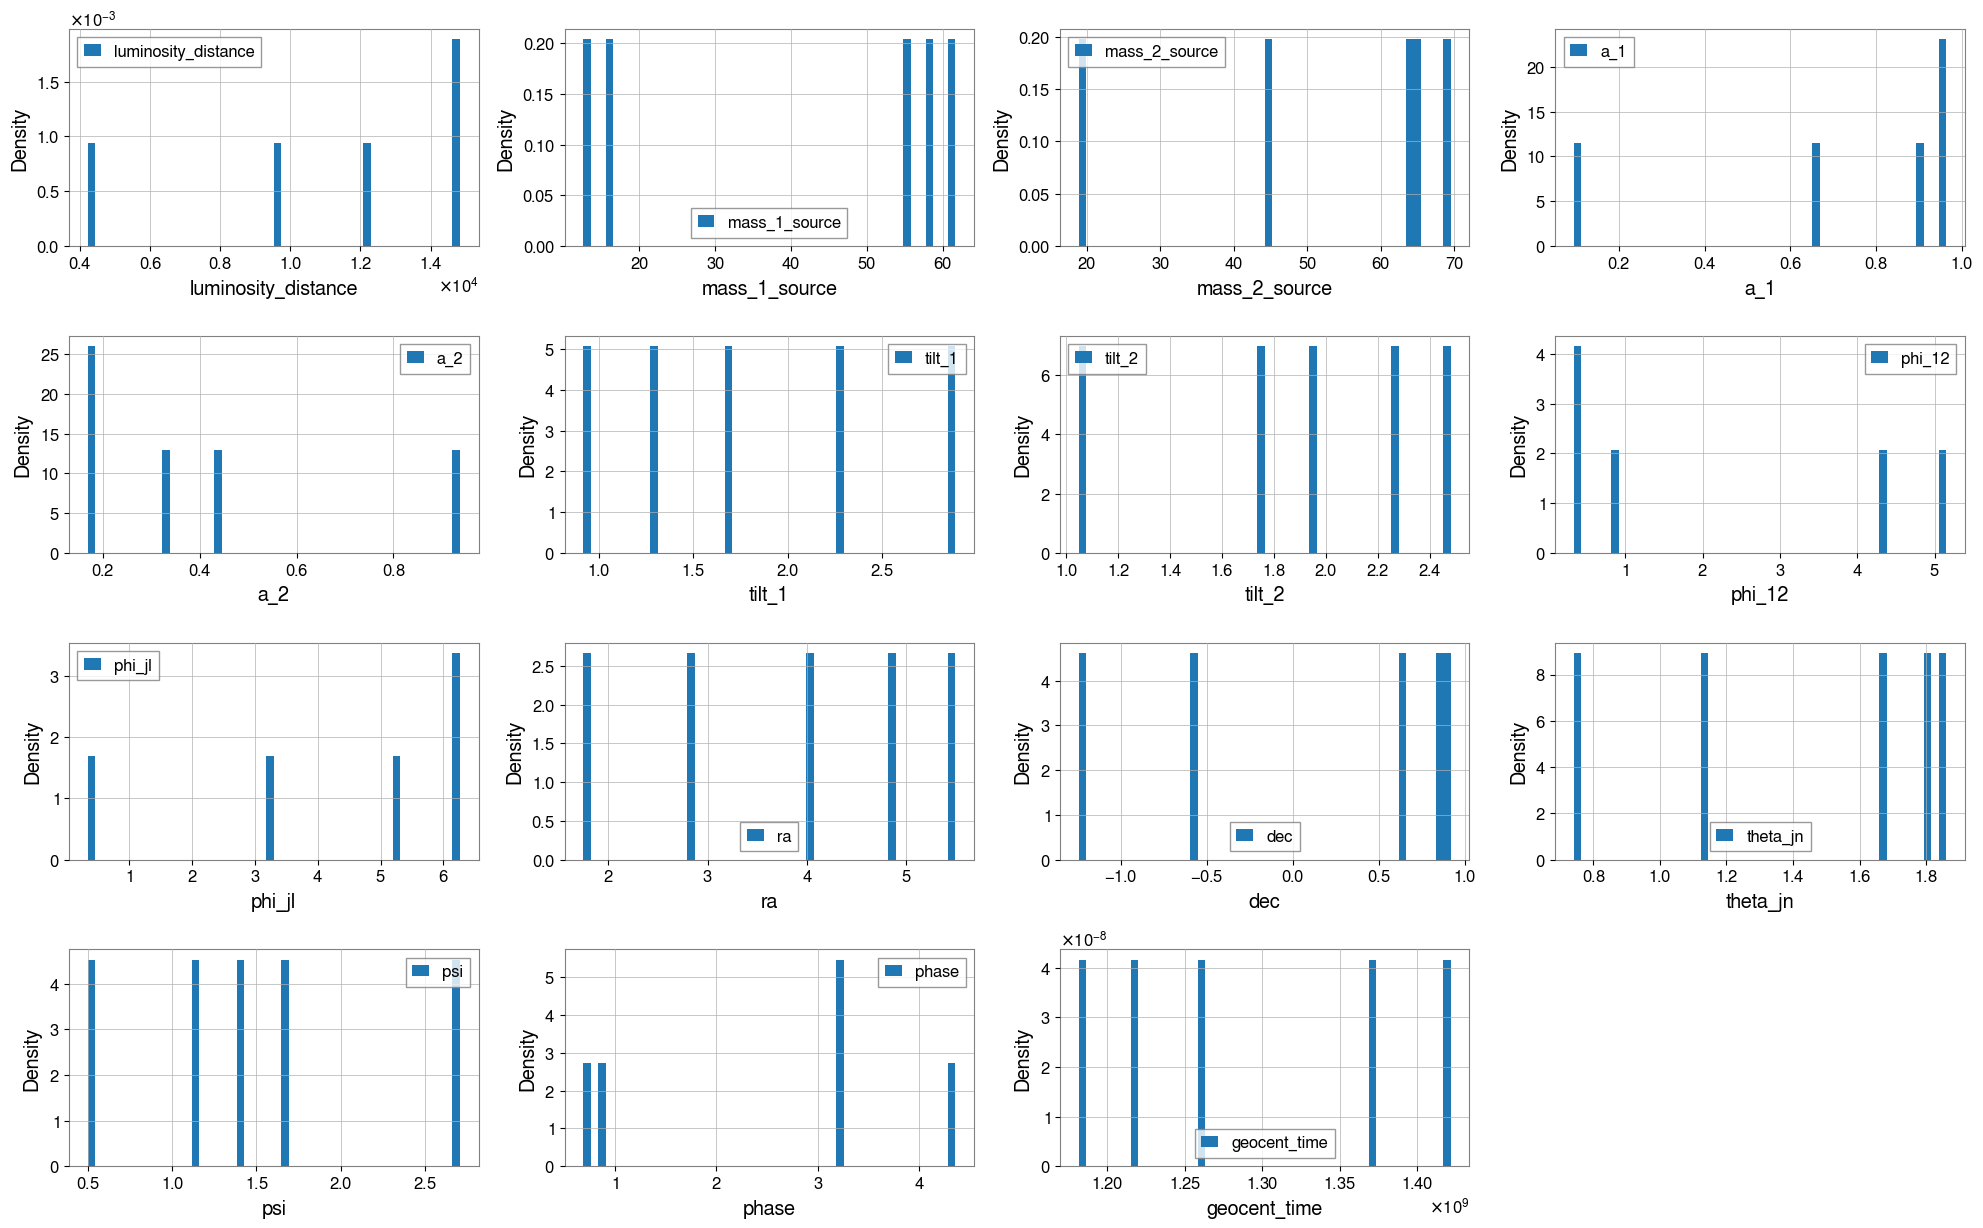

In [7]:
bilby.core.utils.random.seed(n)


# sampling from priors
def prior_GW():
    priors = bilby.core.prior.PriorDict()
    priors['luminosity_distance']=bilby.gw.prior.UniformComovingVolume(
        name="luminosity_distance", minimum=d_L_min, maximum=d_L_max, latex_label="r'$d_L$ (Mpc)'")
    priors['mass_1_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_1_source')
    priors['mass_2_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_2_source')
    priors['a_1']= bilby.core.prior.Uniform(0, 0.99, 'a_1')
    priors['a_2']= bilby.core.prior.Uniform(0, 0.99, 'a_2')
    priors['tilt_1']= bilby.core.prior.Sine(name='tilt_1')
    priors['tilt_2']= bilby.core.prior.Sine(name='tilt_2')
    priors['phi_12']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_12', boundary='periodic')
    priors['phi_jl']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_jl', boundary='periodic')
    priors['ra']= bilby.core.prior.Uniform(0, 2 * np.pi, 'ra', boundary='periodic')
    priors['dec']= bilby.core.prior.Cosine(name='dec')
    priors['theta_jn']= bilby.core.prior.Sine(name='theta_jn')
    priors['psi']= bilby.core.prior.Uniform(0, np.pi, 'psi', boundary='periodic')
    priors['phase']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phase', boundary='periodic')
    priors['geocent_time']= bilby.core.prior.Uniform(time_start, time_end, 'geocent_time')

    return priors

priors = prior_GW()
samples = priors.sample(n_samples)
print(samples.keys())

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()
for i, key in enumerate(samples.keys()):
    ax = axes[i]
    ax.hist(samples[key], bins=50, density=True, label=key)
    ax.set_xlabel(key)
    ax.set_ylabel('Density')
    ax.legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
# plt.savefig('source_samples.pdf')


# 保存数据
source_params = pd.DataFrame(samples)
source_params.to_csv('source_samples.csv', index=False)
source_params

## 1.2 Lensed GW index
### 从n_samples个波源中，随机挑选n_lens个，作为被透镜化的GW波源
### 运行此单元格，得到透镜化波源(第一个像)在source_samples中对应的index及参数，并保存index至文件 lensed_index.csv

In [8]:
source_params=pd.read_csv('source_samples.csv')

np.random.seed(n)
idx = np.random.choice(n_samples, n_lens, replace=False)
idx = np.sort(idx)

print(idx)
idx={'lensed_index': idx}
lensed_index=pd.DataFrame(idx)
lensed_index.to_csv('lensed_index.csv', index=False)
lensed_index

lensed_source_1 = source_params.iloc[lensed_index['lensed_index']]
lensed_source_1

[0 1 2 3 4]


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,9602.227273,54.792747,64.325217,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.181402e+09
1,14720.879694,61.647482,69.525697,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.262566e+09
2,14836.237204,16.104107,44.268021,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371904e+09
3,12253.888221,12.581898,65.200287,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.421751e+09
4,4221.020976,58.477472,18.874803,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215457e+09


## 1.3 Lens modeling
### 根据SIS模型，计算透镜放大率和时间延迟

### 透镜参数

z_l: 透镜红移 

z_s: 源红移

sigma_v: 透镜星系的速度色散(km/s) 

y: 无量纲源位置

#### 中间量：

theta_E: 爱因斯坦角(arcsec)

phi: 源在源平面的方位角(rad)

beta_x, beta_y: 源的角位置(arcsec) 

#### 计算量：

mu_1, mu_2: 透镜放大率(第一个像和第二个像)

t_d: 两像之间延迟(s)

### 运行此单元格，将透镜参数保存至文件 lens_params.csv，透镜放大率与相对时间延迟保存至文件 lens.csv

In [9]:
np.random.seed(n)
rng = np.random.default_rng(n)


tmp_params = os.path.join(tmp_dir, "lens_params.tmp.csv")
tmp_lens   = os.path.join(tmp_dir, "lens.tmp.csv")

for p in [tmp_params, tmp_lens]:
    if os.path.exists(p):
        os.remove(p)


pd.DataFrame(columns=["z_l", 
                      "z_s", 
                      "sigma_v",
                      "theta_E(arcsec)", 
                      "y",
                      "beta_x", 
                      "beta_y"]).to_csv(tmp_params, index=False)

pd.DataFrame(columns=["mu_0",
                      "mu_1", 
                      "t_d"]).to_csv(tmp_lens, index=False)


for i in range(n_lens):
    # 源红移
    dL = lensed_source_1.iloc[i]['luminosity_distance']
    z_s = luminosity_distance_to_redshift(dL, cosmology=cosmo)

    # 透镜红移（这里取源红移的一半）
    z_l = z_s / 2

    # 速度弥散 (km/s)
    sigma_v = np.random.uniform(100, 500)

    lens_cosmo = LensCosmo(z_lens=z_l, z_source=z_s, cosmo=cosmo)

    # 计算 Einstein radius (arcsec)
    theta_E = lens_cosmo.sis_sigma_v2theta_E(sigma_v)

    print('z_s =', z_s)
    print('z_l =', z_l)
    print('sigma_v =', sigma_v)
    print('theta_E =', theta_E)
    

    # 随机生成源平面位置与方向角度
    y = np.random.uniform(0.01, 0.3)
    phi= np.random.uniform(0, 2*np.pi)
    beta_x= y*theta_E* np.cos(phi)
    beta_y= y*theta_E* np.sin(phi)

    print('y =', y)
    print('beta_x =', beta_x)
    print('beta_y =', beta_y)

    mu_plus=1+(1/y)
    mu_minus=1-(1/y) if (y <= 1) else np.nan
  
    Dls=(lens_cosmo.dds*units.Mpc).to(units.m).value
    Dl=(lens_cosmo.dd*units.Mpc).to(units.m).value
    Ds=(lens_cosmo.ds*units.Mpc).to(units.m).value


    t_d=8*4*np.pi**2*(sigma_v*1000)**4*(1+z_l)*Dls*Dl*y/(Ds*const.c.value**5)
    print(mu_plus, mu_minus)
    print(t_d,'s','=',t_d/(24*3600),'days')
    print()

    row_0 = pd.DataFrame([{
        "z_l": z_l,
        "z_s": z_s,
        "sigma_v": sigma_v,
        "theta_E(arcsec)": theta_E,
        "y": y,
        "beta_x": beta_x,
        "beta_y": beta_y}])
    
    row_1 = pd.DataFrame([{
        "mu_0": mu_plus,
        "mu_1": mu_minus,
        "t_d": t_d}])

    row_0.to_csv(tmp_params, mode="a", header=False, index=False)
    row_1.to_csv(tmp_lens,   mode="a", header=False, index=False)


final_params = "lens_params.csv"
final_lens = "lens.csv"

for p in [final_params, final_lens]:
    if os.path.exists(p):
        os.remove(p)
        
shutil.move(tmp_params, final_params)
shutil.move(tmp_lens, final_lens)

z_s = 1.3244032782722936
z_l = 0.6622016391361468
sigma_v = 259.7790680776369
theta_E = 0.7847233714036758
y = 0.2791902720400027
beta_x = -0.03399481297587838
beta_y = -0.2164336477917264
4.581786688673446 -2.581786688673447
5086529.914044617 s = 58.871874005146026 days

z_s = 1.875373446143991
z_l = 0.9376867230719955
sigma_v = 480.54150408452847
theta_E = 2.447808550043939
y = 0.18581900250276426
beta_x = -0.16205805872768622
beta_y = 0.42500013000939246
6.381580928382844 -4.381580928382844
47456420.70077226 s = 549.2641284811605 days

z_s = 1.8873836716145926
z_l = 0.9436918358072963
sigma_v = 101.72080385150291
theta_E = 0.10946960699788916
y = 0.10794091651336826
beta_x = 0.011523178464199254
beta_y = 0.0026153614060862285
10.264327488604861 -8.264327488604861
55505.11185811907 s = 0.6424202761356373 days

z_s = 1.614692584070362
z_l = 0.807346292035181
sigma_v = 168.06098859064664
theta_E = 0.31253689335891544
y = 0.1512334411375275
beta_x = -0.03008120505977295
beta_y = 0.03645

'lens.csv'

## 1.4 All lensed GW source
### 透镜产生双像，所以n_lens个透镜会产生 2 * n_lens个像，相当于有 2 * n_lens组源的参数和data
### 运行此单元格，产生第二个像的源参数（伪源参数，t_2=t_1+t_d，其余参数保持一致）,保存所有透镜化GW源的参数至文件 lensed_source_samples.csv

In [10]:
lens=pd.read_csv('lens.csv')

t_d=[]
for i in range(len(lens)):
    t_d.append((lens['t_d'][i]))
print(t_d)

original_times = lensed_source_1['geocent_time'].values
# print(original_times)

geocent_time_2 = original_times + t_d
# print(geocent_time_2)

lensed_source_2 = lensed_source_1.copy()
lensed_source_2['geocent_time'] = geocent_time_2

lensed_source_params = pd.concat([lensed_source_1, lensed_source_2], axis=0, ignore_index=False)
lensed_source_params.to_csv('lensed_source_samples.csv', index=False)

lensed_source_params


[5086529.914044617, 47456420.70077226, 55505.11185811907, 538074.8841654754, 461041.8305664373]


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,9602.227273,54.792747,64.325217,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.181402e+09
1,14720.879694,61.647482,69.525697,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.262566e+09
2,14836.237204,16.104107,44.268021,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371904e+09
3,12253.888221,12.581898,65.200287,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.421751e+09
4,4221.020976,58.477472,18.874803,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215457e+09
0,9602.227273,54.792747,64.325217,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.186488e+09
1,14720.879694,61.647482,69.525697,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.310023e+09
2,14836.237204,16.104107,44.268021,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371959e+09
3,12253.888221,12.581898,65.200287,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.422289e+09
4,4221.020976,58.477472,18.874803,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215918e+09


## 1.5 Test unlensed GW source
### 对于每一个透镜信号,生成m个非透镜化GW波源参数，总共2 * n_lens * m个非透镜信号作为测试集（给每个透镜像生成 m 个带随机扰动的测试像）。其中dL_test=random number + dL / sqrt(mu)，即通过光度距离缩放来模拟放大率的影响，并加上一个随机数以达到波形相似；geocent_time同样加上一个随机数，其余参数保持不变
### 运行此单元格，产生非透镜化的测试源参数，保存至文件 test_source_samples.csv

In [11]:
np.random.seed(n)

m = 2

# 原始远处透镜源的红移
z_s = luminosity_distance_to_redshift(lensed_source_1['luminosity_distance'].values)
print(z_s)

# 用放大率缩放得到“等效非透镜距离”
d_L_new_1 = lensed_source_1['luminosity_distance'].values / np.sqrt(lens['mu_0'].values)
d_L_new_2 = lensed_source_2['luminosity_distance'].values / np.sqrt(np.abs(lens['mu_1'].values))

print(d_L_new_1)
print(d_L_new_2)

d_L_test_1 = []
time_test_1 = []
d_L_test_2 = []
time_test_2 = []

for i in range(len(d_L_new_1)):
    d_L_t_1 = d_L_new_1[i] + np.random.uniform(-100, 100, m)
    time_t_1 = original_times[i] + np.random.uniform(-100, 100, m)
    d_L_test_1.append(d_L_t_1)
    time_test_1.append(time_t_1)

    d_L_t_2 = d_L_new_2[i] + np.random.uniform(-100, 100, m)
    time_t_2 = geocent_time_2[i] + np.random.uniform(-100, 100, m)
    d_L_test_2.append(d_L_t_2)
    time_test_2.append(time_t_2)

print(d_L_test_1)
print(time_test_1)
print(d_L_test_2)
print(time_test_2)

tmp_test_source_1 = os.path.join(tmp_dir, "test_source_samples_1.tmp.csv")
tmp_test_source_2 = os.path.join(tmp_dir, "test_source_samples_2.tmp.csv")

for p in [tmp_test_source_1, tmp_test_source_2]:
    if os.path.exists(p):
        os.remove(p)

columns = [
    'luminosity_distance',
    'mass_1_source',
    'mass_2_source',
    'a_1',
    'a_2',
    'tilt_1',
    'tilt_2',
    'phi_12',
    'phi_jl',
    'ra',
    'dec',
    'theta_jn',
    'psi',
    'phase',
    'geocent_time']

pd.DataFrame(columns=columns).to_csv(tmp_test_source_1, index=False)
pd.DataFrame(columns=columns).to_csv(tmp_test_source_2, index=False)

source_test_1 = lensed_source_1.copy()
source_test_2 = lensed_source_2.copy()

for i in range(len(source_test_1)):
    for j in range(m):


        # 第 1 个像对应的测试非透镜源
        dL1_test = d_L_test_1[i][j]
        z1_test = luminosity_distance_to_redshift(dL1_test)

        # 原始远处透镜源的 detector-frame mass
        m1_det_1 = source_test_1.iloc[i]['mass_1_source'] * (1 + z_s[i])
        m2_det_1 = source_test_1.iloc[i]['mass_2_source'] * (1 + z_s[i])

        # 更近非透镜测试源的 source-frame mass
        # 使得 m_source_test * (1 + z_test) = m_source_lensed * (1 + z_s)
        m1_src_test_1 = m1_det_1 / (1 + z1_test)
        m2_src_test_1 = m2_det_1 / (1 + z1_test)

        para_1 = pd.DataFrame([{
            'luminosity_distance': dL1_test,
            'mass_1_source': m1_src_test_1,
            'mass_2_source': m2_src_test_1,
            'a_1': source_test_1.iloc[i]['a_1'],
            'a_2': source_test_1.iloc[i]['a_2'],
            'tilt_1': source_test_1.iloc[i]['tilt_1'],
            'tilt_2': source_test_1.iloc[i]['tilt_2'],
            'phi_12': source_test_1.iloc[i]['phi_12'],
            'phi_jl': source_test_1.iloc[i]['phi_jl'],
            'ra': source_test_1.iloc[i]['ra'],
            'dec': source_test_1.iloc[i]['dec'],
            'theta_jn': source_test_1.iloc[i]['theta_jn'],
            'psi': source_test_1.iloc[i]['psi'],
            'phase': source_test_1.iloc[i]['phase'],
            'geocent_time': time_test_1[i][j]
        }])

        # =====================================================
        # 第 2 个像对应的测试非透镜源
        # =====================================================
        dL2_test = d_L_test_2[i][j]
        z2_test = luminosity_distance_to_redshift(dL2_test)

        m1_det_2 = source_test_2.iloc[i]['mass_1_source'] * (1 + z_s[i])
        m2_det_2 = source_test_2.iloc[i]['mass_2_source'] * (1 + z_s[i])

        m1_src_test_2 = m1_det_2 / (1 + z2_test)
        m2_src_test_2 = m2_det_2 / (1 + z2_test)

        para_2 = pd.DataFrame([{
            'luminosity_distance': dL2_test,
            'mass_1_source': m1_src_test_2,
            'mass_2_source': m2_src_test_2,
            'a_1': source_test_2.iloc[i]['a_1'],
            'a_2': source_test_2.iloc[i]['a_2'],
            'tilt_1': source_test_2.iloc[i]['tilt_1'],
            'tilt_2': source_test_2.iloc[i]['tilt_2'],
            'phi_12': source_test_2.iloc[i]['phi_12'],
            'phi_jl': source_test_2.iloc[i]['phi_jl'],
            'ra': source_test_2.iloc[i]['ra'],
            'dec': source_test_2.iloc[i]['dec'],
            'theta_jn': source_test_2.iloc[i]['theta_jn'],
            'psi': source_test_2.iloc[i]['psi'],
            'phase': source_test_2.iloc[i]['phase'],
            'geocent_time': time_test_2[i][j]
        }])

        para_1.to_csv(tmp_test_source_1, mode="a", header=False, index=False)
        para_2.to_csv(tmp_test_source_2, mode="a", header=False, index=False)

final_test_source_1 = "test_source_samples_1.csv"
final_test_source_2 = "test_source_samples_2.csv"

for p in [final_test_source_1, final_test_source_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_test_source_1, final_test_source_1)
shutil.move(tmp_test_source_2, final_test_source_2)

test_source_samples_1 = pd.read_csv(final_test_source_1)
test_source_samples_2 = pd.read_csv(final_test_source_2)

test_source_samples_1

[1.32440328 1.87537345 1.88738367 1.61469258 0.67848875]
[4485.95123154 5827.33013583 4630.82658948 4441.36159875  743.50335251]
[5976.01669818 7032.63932246 5160.83541329 5172.53813713  767.70384799]
[array([4465.84076558, 4571.59969501]), array([5734.43431062, 5761.36063013]), array([4588.28533602, 4605.56418998]), array([4436.54087107, 4431.55544488]), array([651.9331096 , 819.75307376])]
[array([1.18140188e+09, 1.18140193e+09]), array([1.26256614e+09, 1.26256612e+09]), array([1.37190406e+09, 1.37190388e+09]), array([1.42175090e+09, 1.42175072e+09]), array([1.21545675e+09, 1.21545669e+09])]
[array([5997.27118267, 5937.61253008]), array([7020.29516714, 6947.82540487]), array([5127.50484271, 5252.83814193]), array([5148.61055442, 5246.27752548]), array([845.48666793, 813.59425492])]
[array([1.18648827e+09, 1.18648833e+09]), array([1.31002258e+09, 1.31002249e+09]), array([1.37195955e+09, 1.37195941e+09]), array([1.42228895e+09, 1.42228892e+09]), array([1.21591783e+09, 1.21591781e+09])]

,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,4465.840766,74.453148,87.406002,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.181402e+09
1,4571.599695,73.859101,86.708607,0.963282,0.432584,1.274647,1.047099,0.377958,5.268854,1.746815,-1.245049,1.860703,2.709265,0.903457,1.181402e+09
2,5734.434311,94.712228,106.815939,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.262566e+09
3,5761.360630,94.544044,106.626263,0.095290,0.169048,0.917016,2.481314,4.358310,3.256424,5.493501,0.842512,0.741488,1.415300,0.690629,1.262566e+09
4,4588.285336,26.931829,74.031969,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371904e+09
5,4605.564190,26.896940,73.936064,0.653352,0.323324,2.276749,1.738828,5.151226,0.345007,4.044168,0.642385,1.660011,1.659648,3.202500,1.371904e+09
6,4436.540871,19.274683,99.882776,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.421751e+09
7,4431.555445,19.282040,99.920900,0.894912,0.169104,2.889152,2.261031,0.841509,6.211823,4.868733,0.919228,1.127663,0.498480,3.225544,1.421751e+09
8,651.933110,86.553055,27.936772,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215457e+09
9,819.753074,84.229883,27.186921,0.951217,0.937260,1.681977,1.946352,0.337447,6.262744,2.858625,-0.583905,1.794473,1.123166,4.354472,1.215457e+09


# 2. Lensed waveform
## 透镜化波形（一键运行即可，生成data时需要）

In [12]:
def lens_SIS_ampfac(mu_0, mu_1, t_d, frequencies, which_image):

    mu = np.array([mu_0, mu_1])
    n = np.array([0, 1/2])

    if which_image == 0:
        i = 0

    elif which_image == 1:
        i = 1

    else:
        raise ValueError("which_image should be either 0 or 1")

    # 不再加入时延,由注入的geocent_time控制
    F = np.sqrt(np.abs(mu[i])) * np.exp(-1j * np.pi * n[i])

    return {
        'F': F,
        'mu': mu[i],
        't_d': t_d,
        'n': n[i]}


def lensed_waveform_F(frequency_array, mass_1, mass_2, a_1, a_2, tilt_1, tilt_2, phi_12, phi_jl,
                    luminosity_distance, theta_jn, psi, phase, geocent_time, ra, dec, 
                    mu_0, mu_1, t_d, which_image,**kwargs):

    # GW waveform
    params = {
        'mass_1': mass_1, 'mass_2': mass_2, 'a_1': a_1, 'a_2': a_2,
        'tilt_1': tilt_1, 'tilt_2': tilt_2, 'phi_12': phi_12, 'phi_jl': phi_jl,
        'luminosity_distance': luminosity_distance, 'theta_jn': theta_jn,
        'psi': psi, 'phase': phase, 'geocent_time': geocent_time,
        'ra': ra, 'dec': dec}
    
    h = bilby.gw.source.lal_binary_black_hole(frequency_array,**params,**kwargs) 

    z_s = luminosity_distance_to_redshift(luminosity_distance)
    print('z_s:', z_s)

    F = lens_SIS_ampfac(mu_0, mu_1, t_d, frequency_array, which_image)
    print('mu:', F['mu'])
    print('time delay(s):', str(F['t_d'])+' s'+' = '+str(F['t_d']/(24*60*60))+' days')
    print('Morse indice:', F['n'])
    print()

    return {'plus': h['plus'] * F['F'], 'cross': h['cross'] * F['F']}

# 3. GW data

## 3.1 Lensed event data
### 3.1.1 First image data
### 直接运行此单元格,得到透镜化GW的第一个像的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

### aLIGO

In [ ]:
bilby.core.utils.random.seed(n + 1)

N = int(sampling_frequency * duration)

waveform_arguments = dict(
    waveform_approximant='IMRPhenomXPHM',
    reference_frequency=10.,
    minimum_frequency=minimum_frequency
)

# lensed_waveform
waveform_generator_lensed = bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments
)

lensed_source_params = pd.read_csv(os.path.join( 'lensed_source_samples.csv'))
lens = pd.read_csv(os.path.join( 'lens.csv'))
n_events = len(lensed_source_params) // 2

# LIGO
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifo_names = [ifo.name for ifo in ifos]
n_ifos = len(ifos)


# 输出文件
tmp_data_1 = os.path.join(tmp_dir, "SIS_data_strain_1.tmp.npy")
tmp_h_1    = os.path.join(tmp_dir, "SIS_h_strain_1.tmp.npy")
tmp_t_1    = os.path.join(tmp_dir, "SIS_time_array_1.tmp.npy")
tmp_snr_single_1 = os.path.join(tmp_dir, "SIS_optimal_SNR_single_1.tmp.npy")
tmp_snr_net_1    = os.path.join(tmp_dir, "SIS_optimal_SNR_network_1.tmp.npy")


for p in [tmp_data_1, tmp_h_1, tmp_t_1, tmp_snr_single_1, tmp_snr_net_1]:
    if os.path.exists(p):
        os.remove(p)

# shape(n_events, n_ifos, N)
data_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

h_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

t_mm_1 = np.lib.format.open_memmap(
    tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

snr_single_mm_1 = np.lib.format.open_memmap(
    tmp_snr_single_1, mode="w+", dtype=np.float64, shape=(n_events, n_ifos)) # 单探测器optimal SNR

snr_net_mm_1 = np.lib.format.open_memmap(
    tmp_snr_net_1, mode="w+", dtype=np.float64, shape=(n_events,)) # 探测器网络总SNR



# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):
    injection_parameters = {
        **lensed_source_params.iloc[i].to_dict(),
        **lens.iloc[i].to_dict(),
        'which_image': 0
    }

    r = 1500  # 以采样点为单位，控制信号并合时在strain数据中的位置，r越小，并合信号越靠近末尾

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    snr_sq_network = 0.0

    for j, ifo in enumerate(ifos):
        ifo.set_strain_data_from_power_spectral_density(
            sampling_frequency=sampling_frequency,
            duration=duration,
            start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

        n_t = ifo.strain_data.time_domain_strain.copy()
        t_array = ifo.strain_data.time_array.copy()

        n_f_white = ifo.whitened_frequency_domain_strain
        n_t_white = np.fft.irfft(n_f_white, n=N)

        response = ifo.get_detector_response(fd_waveform, injection_parameters)
        snr_squared = np.real(ifo.optimal_snr_squared(response))
        snr = np.sqrt(np.abs(snr_squared))

        snr_single_mm_1[i, j] = snr
        snr_sq_network += np.abs(snr_squared)

        ifo.inject_signal(
            waveform_generator=waveform_generator_lensed,
            parameters=injection_parameters
        )

        d_t = ifo.strain_data.time_domain_strain.copy()

        d_f_white = ifo.whitened_frequency_domain_strain
        d_t_white = np.fft.irfft(d_f_white, n=N)

        h_t = d_t - n_t
        h_t_white = d_t_white - n_t_white

        

        # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
        peak_index = np.argmax(np.abs(h_t_white))

        cut_index = peak_index + int(0.05 * sampling_frequency)
        cut_index = min(cut_index, N)

        h_t_white_new = h_t_white.copy()

        fade_len = N - cut_index
        if fade_len > 0:
            hann_full = np.hanning(2 * fade_len)
            fade_window = hann_full[fade_len:]
            h_t_white_new[cut_index:] *= fade_window

        d_t_white_new = h_t_white_new + n_t_white



        t_mm_1[i, j, :] = t_array
        data_whiten_mm_1[i, j, :] = d_t_white_new
        h_whiten_mm_1[i, j, :] = h_t_white_new

    snr_net_mm_1[i] = np.sqrt(snr_sq_network)

data_whiten_mm_1.flush()
h_whiten_mm_1.flush()
t_mm_1.flush()
snr_single_mm_1.flush()
snr_net_mm_1.flush()

final_data_1 = os.path.join("SIS_data_strain_1.npy")
final_h_1 = os.path.join("SIS_h_strain_1.npy")
final_t_1 = os.path.join("SIS_time_array_1.npy")
final_snr_single_1 = os.path.join("SIS_optimal_SNR_single_1.npy")
final_snr_net_1 = os.path.join("SIS_optimal_SNR_network_1.npy")

for p in [final_data_1, final_h_1, final_t_1, final_snr_single_1, final_snr_net_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_1, final_data_1)
shutil.move(tmp_h_1, final_h_1)
shutil.move(tmp_t_1, final_t_1)
shutil.move(tmp_snr_single_1, final_snr_single_1)
shutil.move(tmp_snr_net_1, final_snr_net_1)


23:22 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
23:22 bilby INFO    : Injected signal in H1:
23:22 bilby INFO    :   optimal SNR = 7.98
23:22 bilby INFO    :   matched filter SNR = 8.78+1.39j
23:22 bilby INFO    :   luminosity_distance = 9602.2272728874
23:22 bilby INFO    :   mass_1_source = 54.79274675583722
23:22 bilby INFO    :   mass_2_source = 64.32521695754403
23:22 bilby INFO    :   a_1 = 0.9632817587559832
23:22 bilby INFO    :   a_2 = 0.4325838577110681
23:22 bilby INFO    :   tilt_1 = 1.274646637615504
23:22 bilby INFO    :   tilt_2 = 1.047099480977744
23:22 bilby INFO    :   phi_12 = 0.3779581473171579
23:22 bilby INFO    :   phi_jl = 5.268854046814757
23:22 bilby INFO    :   ra = 1.7468146863437164
23:22 bilby INFO    :   dec = -1.245048666432323
23:22 bilby INFO    :   theta_jn = 1.8607

z_s: 1.3244032782722936
mu: 4.581786688673446
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.875373446143991
mu: 6.381580928382844
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



23:22 bilby INFO    : Injected signal in H1:
23:22 bilby INFO    :   optimal SNR = 12.25
23:22 bilby INFO    :   matched filter SNR = 14.63+0.37j
23:22 bilby INFO    :   luminosity_distance = 14720.879693794535
23:22 bilby INFO    :   mass_1_source = 61.64748185374658
23:22 bilby INFO    :   mass_2_source = 69.52569730616929
23:22 bilby INFO    :   a_1 = 0.0952900623738693
23:22 bilby INFO    :   a_2 = 0.1690476177587783
23:22 bilby INFO    :   tilt_1 = 0.9170159160407498
23:22 bilby INFO    :   tilt_2 = 2.481314440267226
23:22 bilby INFO    :   phi_12 = 4.358309750590284
23:22 bilby INFO    :   phi_jl = 3.2564237986976865
23:22 bilby INFO    :   ra = 5.493500667873665
23:22 bilby INFO    :   dec = 0.8425120073581721
23:22 bilby INFO    :   theta_jn = 0.7414877518357127
23:22 bilby INFO    :   psi = 1.4152995282992098
23:22 bilby INFO    :   phase = 0.6906292638092209
23:22 bilby INFO    :   geocent_time = 1262566146.9209452
23:22 bilby INFO    :   mu_0 = 6.381580928382844
23:22 bilby 

z_s: 1.8873836716145926
mu: 10.26432748860486
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.614692584070362
mu: 7.612294162444057
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



23:22 bilby INFO    : Injected signal in H1:
23:22 bilby INFO    :   optimal SNR = 3.59
23:22 bilby INFO    :   matched filter SNR = 5.01-0.99j
23:22 bilby INFO    :   luminosity_distance = 12253.888221233725
23:22 bilby INFO    :   mass_1_source = 12.581897558703584
23:22 bilby INFO    :   mass_2_source = 65.20028730008954
23:22 bilby INFO    :   a_1 = 0.8949121309757863
23:22 bilby INFO    :   a_2 = 0.1691044612880276
23:22 bilby INFO    :   tilt_1 = 2.889152314412773
23:22 bilby INFO    :   tilt_2 = 2.2610307235815976
23:22 bilby INFO    :   phi_12 = 0.8415090594314173
23:22 bilby INFO    :   phi_jl = 6.2118229916220535
23:22 bilby INFO    :   ra = 4.868733495132442
23:22 bilby INFO    :   dec = 0.9192279325551708
23:22 bilby INFO    :   theta_jn = 1.1276626630552626
23:22 bilby INFO    :   psi = 0.4984796275671821
23:22 bilby INFO    :   phase = 3.2255436304718663
23:22 bilby INFO    :   geocent_time = 1421750812.9120257
23:22 bilby INFO    :   mu_0 = 7.612294162444057
23:22 bilby 

z_s: 0.6784887514882153
mu: 32.23065700551
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



'SIS_optimal_SNR_network_1.npy'

### ET single

In [ ]:
bilby.core.utils.random.seed(n+1)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# lensed_waveform 
waveform_generator_lensed=bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)

lensed_source_params=pd.read_csv('lensed_source_samples.csv')
lens = pd.read_csv('lens.csv')
n_events = len(lensed_source_params)//2


tmp_data_1 = os.path.join(tmp_dir, "SIS_data_strain_1.tmp.npy")
tmp_h_1    = os.path.join(tmp_dir, "SIS_h_strain_1.tmp.npy")
tmp_t_1    = os.path.join(tmp_dir, "SIS_time_array_1.tmp.npy")
tmp_snr_1  = os.path.join(tmp_dir, "SIS_optimal_SNR_1.tmp.npy")

for p in [tmp_data_1, tmp_h_1, tmp_t_1, tmp_snr_1]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events, N))
h_whiten_mm_1 = np.lib.format.open_memmap(
    tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events, N))
t_mm_1 = np.lib.format.open_memmap(
    tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events, N))
snr_mm_1 = np.lib.format.open_memmap(
    tmp_snr_1, mode="w+", dtype=np.float64, shape=(n_events,))




ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):

    # 取出一组参数
    injection_parameters = {**lensed_source_params.iloc[i].to_dict(),   # 将第 i 行转换为字典
                            **lens.iloc[i].to_dict(),
                            'which_image':0} 

    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)


    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator_lensed, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white



    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white



    t_mm_1[i, :] = t_array
    snr_mm_1[i] = snr
    data_whiten_mm_1[i, :] = d_t_white_new
    h_whiten_mm_1[i, :] = h_t_white_new


data_whiten_mm_1.flush()
h_whiten_mm_1.flush()
t_mm_1.flush()
snr_mm_1.flush()

final_data_1 = "SIS_data_strain_1.npy"
final_h_1  = "SIS_h_strain_1.npy"
final_t_1   = "SIS_time_array_1.npy"
final_snr_1 = "SIS_optimal_SNR_1.npy"

for p in [final_data_1, final_h_1, final_t_1, final_snr_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_1, final_data_1)
shutil.move(tmp_h_1, final_h_1)
shutil.move(tmp_t_1, final_t_1)
shutil.move(tmp_snr_1, final_snr_1)

20:30 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:30 bilby INFO    : Injected signal in ET1:
20:30 bilby INFO    :   optimal SNR = 37.63
20:30 bilby INFO    :   matched filter SNR = 36.39-0.47j
20:30 bilby INFO    :   luminosity_distance = 9602.2272728874
20:30 bilby INFO    :   mass_1_source = 54.79274675583722
20:30 bilby INFO    :   mass_2_source = 64.32521695754403
20:30 bilby INFO    :   a_1 = 0.9632817587559832
20:30 bilby INFO    :   a_2 = 0.4325838577110681
20:30 bilby INFO    :   tilt_1 = 1.274646637615504
20:30 bilby INFO    :   tilt_2 = 1.047099480977744
20:30 bilby INFO    :   phi_12 = 0.3779581473171579
20:30 bilby INFO    :   phi_jl = 5.268854046814757
20:30 bilby INFO    :   ra = 1.7468146863437164
20:30 bilby INFO    :   dec = -1.245048666432323
20:30 bilby INFO    :   theta_jn = 1.8

z_s: 1.3244032782722936
mu: 4.581786688673446
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.875373446143991
mu: 6.381580928382844
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



20:30 bilby INFO    : Injected signal in ET1:
20:30 bilby INFO    :   optimal SNR = 22.37
20:30 bilby INFO    :   matched filter SNR = 23.07+0.95j
20:30 bilby INFO    :   luminosity_distance = 14836.23720355127
20:30 bilby INFO    :   mass_1_source = 16.10410722991533
20:30 bilby INFO    :   mass_2_source = 44.26802138594695
20:30 bilby INFO    :   a_1 = 0.653351646184752
20:30 bilby INFO    :   a_2 = 0.3233242624883724
20:30 bilby INFO    :   tilt_1 = 2.2767492626520496
20:30 bilby INFO    :   tilt_2 = 1.7388279294103517
20:30 bilby INFO    :   phi_12 = 5.151226114379203
20:30 bilby INFO    :   phi_jl = 0.3450066035632245
20:30 bilby INFO    :   ra = 4.044168265545273
20:30 bilby INFO    :   dec = 0.6423849645751639
20:30 bilby INFO    :   theta_jn = 1.6600108316474993
20:30 bilby INFO    :   psi = 1.6596484570567407
20:30 bilby INFO    :   phase = 3.2024997504973545
20:30 bilby INFO    :   geocent_time = 1371903981.023374
20:30 bilby INFO    :   mu_0 = 10.26432748860486
20:30 bilby I

z_s: 1.8873836716145926
mu: 10.26432748860486
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0

z_s: 1.614692584070362
mu: 7.612294162444057
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



20:30 bilby INFO    : Injected signal in ET1:
20:30 bilby INFO    :   optimal SNR = 144.33
20:30 bilby INFO    :   matched filter SNR = 145.60-1.01j
20:30 bilby INFO    :   luminosity_distance = 4221.02097612546
20:30 bilby INFO    :   mass_1_source = 58.47747211482589
20:30 bilby INFO    :   mass_2_source = 18.87480272607484
20:30 bilby INFO    :   a_1 = 0.9512174497708088
20:30 bilby INFO    :   a_2 = 0.9372603329551346
20:30 bilby INFO    :   tilt_1 = 1.68197718056495
20:30 bilby INFO    :   tilt_2 = 1.9463518893804768
20:30 bilby INFO    :   phi_12 = 0.3374473619138041
20:30 bilby INFO    :   phi_jl = 6.26274351071372
20:30 bilby INFO    :   ra = 2.858625229030752
20:30 bilby INFO    :   dec = -0.5839052936446072
20:30 bilby INFO    :   theta_jn = 1.794473079588927
20:30 bilby INFO    :   psi = 1.1231663350478025
20:30 bilby INFO    :   phase = 4.35447181580713
20:30 bilby INFO    :   geocent_time = 1215456771.391391
20:30 bilby INFO    :   mu_0 = 32.23065700551
20:30 bilby INFO   

z_s: 0.6784887514882153
mu: 32.23065700551
time delay(s): 0.0 s = 0.0 days
Morse indice: 0.0



'SIS_optimal_SNR_1.npy'

### 3.1.2 Second image data
### 直接运行此单元格,得到透镜化GW的第二个像的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

### aLIGO

In [ ]:
bilby.core.utils.random.seed(n + 2)

N = int(sampling_frequency * duration)

waveform_arguments = dict(
    waveform_approximant='IMRPhenomXPHM',
    reference_frequency=10.,
    minimum_frequency=minimum_frequency
)

waveform_generator_lensed = bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments
)

# LIGO
ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifo_names = [ifo.name for ifo in ifos]
n_ifos = len(ifos)

tmp_data_2 = os.path.join(tmp_dir, "SIS_data_strain_2.tmp.npy")
tmp_h_2    = os.path.join(tmp_dir, "SIS_h_strain_2.tmp.npy")
tmp_t_2    = os.path.join(tmp_dir, "SIS_time_array_2.tmp.npy")
tmp_snr_single_2 = os.path.join(tmp_dir, "SIS_optimal_SNR_single_2.tmp.npy")
tmp_snr_net_2    = os.path.join(tmp_dir, "SIS_optimal_SNR_network_2.tmp.npy")

for p in [tmp_data_2, tmp_h_2, tmp_t_2, tmp_snr_single_2, tmp_snr_net_2]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

h_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

t_mm_2 = np.lib.format.open_memmap(
    tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N))

snr_single_mm_2 = np.lib.format.open_memmap(
    tmp_snr_single_2, mode="w+", dtype=np.float64, shape=(n_events, n_ifos))

snr_net_mm_2 = np.lib.format.open_memmap(
    tmp_snr_net_2, mode="w+", dtype=np.float64, shape=(n_events,))

for i in range(n_events):
    injection_parameters = {
        **lensed_source_params.iloc[i + n_events].to_dict(),
        **lens.iloc[i].to_dict(),
        'which_image': 1
    }

    r = 1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    snr_sq_network = 0.0

    for j, ifo in enumerate(ifos):
        ifo.set_strain_data_from_power_spectral_density(
            sampling_frequency=sampling_frequency,
            duration=duration,
            start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

        n_t = ifo.strain_data.time_domain_strain.copy()
        t_array = ifo.strain_data.time_array.copy()

        n_f_white = ifo.whitened_frequency_domain_strain
        n_t_white = np.fft.irfft(n_f_white, n=N)

        response = ifo.get_detector_response(fd_waveform, injection_parameters)
        snr_squared = np.real(ifo.optimal_snr_squared(response))
        snr = np.sqrt(np.abs(snr_squared))

        snr_single_mm_2[i, j] = snr
        snr_sq_network += np.abs(snr_squared)

        ifo.inject_signal(
            waveform_generator=waveform_generator_lensed,
            parameters=injection_parameters
        )

        d_t = ifo.strain_data.time_domain_strain.copy()

        d_f_white = ifo.whitened_frequency_domain_strain
        d_t_white = np.fft.irfft(d_f_white, n=N)

        h_t = d_t - n_t
        h_t_white = d_t_white - n_t_white

        # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
        peak_index = np.argmax(np.abs(h_t_white))

        cut_index = peak_index + int(0.05 * sampling_frequency)
        cut_index = min(cut_index, N)

        h_t_white_new = h_t_white.copy()

        fade_len = N - cut_index
        if fade_len > 0:
            hann_full = np.hanning(2 * fade_len)
            fade_window = hann_full[fade_len:]
            h_t_white_new[cut_index:] *= fade_window

        d_t_white_new = h_t_white_new + n_t_white


        t_mm_2[i, j, :] = t_array
        data_whiten_mm_2[i, j, :] = d_t_white_new
        h_whiten_mm_2[i, j, :] = h_t_white_new

    snr_net_mm_2[i] = np.sqrt(snr_sq_network)

data_whiten_mm_2.flush()
h_whiten_mm_2.flush()
t_mm_2.flush()
snr_single_mm_2.flush()
snr_net_mm_2.flush()

final_data_2 = os.path.join( "SIS_data_strain_2.npy")
final_h_2    = os.path.join( "SIS_h_strain_2.npy")
final_t_2    = os.path.join( "SIS_time_array_2.npy")
final_snr_single_2 = os.path.join( "SIS_optimal_SNR_single_2.npy")
final_snr_net_2    = os.path.join( "SIS_optimal_SNR_network_2.npy")

for p in [final_data_2, final_h_2, final_t_2, final_snr_single_2, final_snr_net_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_2, final_data_2)
shutil.move(tmp_h_2, final_h_2)
shutil.move(tmp_t_2, final_t_2)
shutil.move(tmp_snr_single_2, final_snr_single_2)
shutil.move(tmp_snr_net_2, final_snr_net_2)

20:31 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: __main__.lensed_waveform_F
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:31 bilby INFO    : Injected signal in ET1:
20:31 bilby INFO    :   optimal SNR = 42.01
20:31 bilby INFO    :   matched filter SNR = 43.27+1.42j
20:31 bilby INFO    :   luminosity_distance = 9602.2272728874
20:31 bilby INFO    :   mass_1_source = 54.79274675583722
20:31 bilby INFO    :   mass_2_source = 64.32521695754403
20:31 bilby INFO    :   a_1 = 0.9632817587559832
20:31 bilby INFO    :   a_2 = 0.4325838577110681
20:31 bilby INFO    :   tilt_1 = 1.274646637615504
20:31 bilby INFO    :   tilt_2 = 1.047099480977744
20:31 bilby INFO    :   phi_12 = 0.3779581473171579
20:31 bilby INFO    :   phi_jl = 5.268854046814757
20:31 bilby INFO    :   ra = 1.7468146863437164
20:31 bilby INFO    :   dec = -1.245048666432323
20:31 bilby INFO    :   theta_jn = 1.8

z_s: 1.3244032782722936
mu: -2.581786688673447
time delay(s): 5086529.914044617 s = 58.871874005146026 days
Morse indice: 0.5

z_s: 1.875373446143991
mu: -4.381580928382844
time delay(s): 47456420.70077226 s = 549.2641284811605 days
Morse indice: 0.5



20:31 bilby INFO    : Injected signal in ET1:
20:31 bilby INFO    :   optimal SNR = 16.84
20:31 bilby INFO    :   matched filter SNR = 16.85+0.08j
20:31 bilby INFO    :   luminosity_distance = 14836.23720355127
20:31 bilby INFO    :   mass_1_source = 16.10410722991533
20:31 bilby INFO    :   mass_2_source = 44.26802138594695
20:31 bilby INFO    :   a_1 = 0.653351646184752
20:31 bilby INFO    :   a_2 = 0.3233242624883724
20:31 bilby INFO    :   tilt_1 = 2.2767492626520496
20:31 bilby INFO    :   tilt_2 = 1.7388279294103517
20:31 bilby INFO    :   phi_12 = 5.151226114379203
20:31 bilby INFO    :   phi_jl = 0.3450066035632245
20:31 bilby INFO    :   ra = 4.044168265545273
20:31 bilby INFO    :   dec = 0.6423849645751639
20:31 bilby INFO    :   theta_jn = 1.6600108316474993
20:31 bilby INFO    :   psi = 1.6596484570567407
20:31 bilby INFO    :   phase = 3.2024997504973545
20:31 bilby INFO    :   geocent_time = 1371959486.1352322
20:31 bilby INFO    :   mu_0 = 10.26432748860486
20:31 bilby 

z_s: 1.8873836716145926
mu: -8.264327488604861
time delay(s): 55505.11185811907 s = 0.6424202761356373 days
Morse indice: 0.5

z_s: 1.614692584070362
mu: -5.612294162444057
time delay(s): 538074.8841654754 s = 6.227718566730039 days
Morse indice: 0.5



20:31 bilby INFO    : Injected signal in ET1:
20:31 bilby INFO    :   optimal SNR = 347.69
20:31 bilby INFO    :   matched filter SNR = 348.07-0.30j
20:31 bilby INFO    :   luminosity_distance = 4221.02097612546
20:31 bilby INFO    :   mass_1_source = 58.47747211482589
20:31 bilby INFO    :   mass_2_source = 18.87480272607484
20:31 bilby INFO    :   a_1 = 0.9512174497708088
20:31 bilby INFO    :   a_2 = 0.9372603329551346
20:31 bilby INFO    :   tilt_1 = 1.68197718056495
20:31 bilby INFO    :   tilt_2 = 1.9463518893804768
20:31 bilby INFO    :   phi_12 = 0.3374473619138041
20:31 bilby INFO    :   phi_jl = 6.26274351071372
20:31 bilby INFO    :   ra = 2.858625229030752
20:31 bilby INFO    :   dec = -0.5839052936446072
20:31 bilby INFO    :   theta_jn = 1.794473079588927
20:31 bilby INFO    :   psi = 1.1231663350478025
20:31 bilby INFO    :   phase = 4.35447181580713
20:31 bilby INFO    :   geocent_time = 1215917813.2219574
20:31 bilby INFO    :   mu_0 = 32.23065700551
20:31 bilby INFO  

z_s: 0.6784887514882153
mu: -30.23065700551
time delay(s): 461041.8305664373 s = 5.336132298222654 days
Morse indice: 0.5



'SIS_optimal_SNR_2.npy'

### ET single

In [ ]:
bilby.core.utils.random.seed(n+2)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# lensed_waveform 
waveform_generator_lensed=bilby.gw.waveform_generator.WaveformGenerator(
    sampling_frequency=sampling_frequency,
    duration=duration,
    frequency_domain_source_model=lensed_waveform_F,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


tmp_data_2 = os.path.join(tmp_dir, "SIS_data_strain_2.tmp.npy")
tmp_h_2    = os.path.join(tmp_dir, "SIS_h_strain_2.tmp.npy")
tmp_t_2    = os.path.join(tmp_dir, "SIS_time_array_2.tmp.npy")
tmp_snr_2  = os.path.join(tmp_dir, "SIS_optimal_SNR_2.tmp.npy")

for p in [tmp_data_2, tmp_h_2, tmp_t_2, tmp_snr_2]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events, N))
h_whiten_mm_2 = np.lib.format.open_memmap(
    tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events, N))
t_mm_2 = np.lib.format.open_memmap(
    tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events, N))
snr_mm_2 = np.lib.format.open_memmap(
    tmp_snr_2, mode="w+", dtype=np.float64, shape=(n_events,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(n_events):

    # 取出一组参数
    injection_parameters = {**lensed_source_params.iloc[i+(len(lensed_source_params)//2)].to_dict(),   # 将第 i 行转换为字典
                            **lens.iloc[i].to_dict(),
                            'which_image':1} 

    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)

    

    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator_lensed, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white

    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white



    t_mm_2[i, :] = t_array
    snr_mm_2[i] = snr
    data_whiten_mm_2[i, :] = d_t_white_new
    h_whiten_mm_2[i, :] = h_t_white_new


data_whiten_mm_2.flush()
h_whiten_mm_2.flush()
t_mm_2.flush()
snr_mm_2.flush()

final_data_2 = "SIS_data_strain_2.npy"
final_h_2   = "SIS_h_strain_2.npy"
final_t_2   = "SIS_time_array_2.npy"
final_snr_2 = "SIS_optimal_SNR_2.npy"

for p in [final_data_2, final_h_2, final_t_2, final_snr_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data_2, final_data_2)
shutil.move(tmp_h_2, final_h_2)
shutil.move(tmp_t_2, final_t_2)
shutil.move(tmp_snr_2, final_snr_2)

## 3.2 Test unlensed data
### 3.2.1  Test data for first image
### 直接运行此单元格,得到透镜化第一个像的相似非透镜化测试集的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

In [ ]:
bilby.core.utils.random.seed(n+3)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# unlensed_waveform 
waveform_generator=bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


test_params = pd.read_csv('test_source_samples_1.csv')
n_events_test = len(test_params)


test_tmp_data_1 = os.path.join(tmp_dir, "test_SIS_data_strain_1.tmp.npy")
test_tmp_h_1    = os.path.join(tmp_dir, "test_SIS_h_strain_1.tmp.npy")
test_tmp_t_1   = os.path.join(tmp_dir, "test_SIS_time_array_1.tmp.npy")
test_tmp_snr_1 = os.path.join(tmp_dir, "test_SIS_optimal_SNR_1.tmp.npy")

for p in [test_tmp_data_1, test_tmp_h_1, test_tmp_t_1, test_tmp_snr_1]:
    if os.path.exists(p):
        os.remove(p)

test_data_whiten_mm_1 = np.lib.format.open_memmap(
    test_tmp_data_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_h_whiten_mm_1 = np.lib.format.open_memmap(
    test_tmp_h_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_t_mm_1 = np.lib.format.open_memmap(
    test_tmp_t_1, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_snr_mm_1 = np.lib.format.open_memmap(
    test_tmp_snr_1, mode="w+", dtype=np.float64, shape=(n_events_test,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(len(test_params)):

    # 取出一组参数
    injection_parameters = test_params.iloc[i].to_dict()   # 将第 i 行转换为字典

    r=1500

    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
         start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)



    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white



   # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white



    test_t_mm_1[i, :] = t_array
    test_snr_mm_1[i] = snr
    test_data_whiten_mm_1[i, :] = d_t_white_new
    test_h_whiten_mm_1[i, :] = h_t_white_new


test_data_whiten_mm_1.flush()
test_h_whiten_mm_1.flush()
test_t_mm_1.flush()
test_snr_mm_1.flush()

test_final_data_1 = "test_SIS_data_strain_1.npy"
test_final_h_1  = "test_SIS_h_strain_1.npy"
test_final_t_1   = "test_SIS_time_array_1.npy"
test_final_snr_1 = "test_SIS_optimal_SNR_1.npy"

for p in [test_final_data_1, test_final_h_1, test_final_t_1, test_final_snr_1]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(test_tmp_data_1, test_final_data_1)
shutil.move(test_tmp_h_1, test_final_h_1)
shutil.move(test_tmp_t_1, test_final_t_1)
shutil.move(test_tmp_snr_1, test_final_snr_1)

20:33 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:33 bilby INFO    : Injected signal in ET1:
20:33 bilby INFO    :   optimal SNR = 38.12
20:33 bilby INFO    :   matched filter SNR = 36.33+0.19j
20:33 bilby INFO    :   luminosity_distance = 4465.840765575185
20:33 bilby INFO    :   mass_1 = 127.3604401848116
20:33 bilby INFO    :   mass_2 = 149.51774517169187
20:33 bilby INFO    :   a_1 = 0.9632817587559832
20:33 bilby INFO    :   a_2 = 0.4325838577110681
20:33 bilby INFO    :   tilt_1 = 1.274646637615504
20:33 bilby INFO    :   tilt_2 = 1.047099480977744
20:33 bilby INFO    :   phi_12 = 0.3779581473171579
20:33 bilby INFO    :   phi_jl = 5.268854046814757
20:33 bilby INFO    :   ra = 1.7468146863437164
20:33 bilby INFO    :   dec = -1.245048666432323
20:33 bilby INFO    :   theta_jn = 1.8

'test_SIS_optimal_SNR_1.npy'

### 3.2.2  Test data for second image
### 直接运行此单元格,得到透镜化第二个像的相似非透镜化测试集的时域数据
### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

In [ ]:
bilby.core.utils.random.seed(n+4)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# unlensed_waveform 
waveform_generator=bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


test_params = pd.read_csv('test_source_samples_2.csv')
n_events_test = len(test_params)


test_tmp_data_2 = os.path.join(tmp_dir, "test_PM_data_strain_2.tmp.npy")
test_tmp_h_2    = os.path.join(tmp_dir, "test_PM_h_strain_2.tmp.npy")
test_tmp_t_2   = os.path.join(tmp_dir, "test_PM_time_array_2.tmp.npy")
test_tmp_snr_2 = os.path.join(tmp_dir, "test_PM_optimal_SNR_2.tmp.npy")

for p in [test_tmp_data_2, test_tmp_h_2, test_tmp_t_2, test_tmp_snr_2]:
    if os.path.exists(p):
        os.remove(p)

test_data_whiten_mm_2 = np.lib.format.open_memmap(
    test_tmp_data_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_h_whiten_mm_2 = np.lib.format.open_memmap(
    test_tmp_h_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_t_mm_2 = np.lib.format.open_memmap(
    test_tmp_t_2, mode="w+", dtype=np.float64, shape=(n_events_test, N))
test_snr_mm_2 = np.lib.format.open_memmap(
    test_tmp_snr_2, mode="w+", dtype=np.float64, shape=(n_events_test,))


ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用一个探测器ET

# 读取每一组参数，计算对应的引力波信号
for i in range(len(test_params)):

    # 取出一组参数
    injection_parameters = test_params.iloc[i].to_dict()   # 将第 i 行转换为字典


    r=1500

    fd_waveform = waveform_generator_lensed.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)


    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white


    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white


    test_t_mm_2[i, :] = t_array
    test_snr_mm_2[i] = snr
    test_data_whiten_mm_2[i, :] = d_t_white_new
    test_h_whiten_mm_2[i, :] = h_t_white_new

test_data_whiten_mm_2.flush()
test_h_whiten_mm_2.flush()
test_t_mm_2.flush()
test_snr_mm_2.flush()

test_final_data_2 = "test_PM_data_strain_2.npy"
test_final_h_2  = "test_PM_h_strain_2.npy"
test_final_t_2   = "test_PM_time_array_2.npy"
test_final_snr_2 = "test_PM_optimal_SNR_2.npy"

for p in [test_final_data_2, test_final_h_2, test_final_t_2, test_final_snr_2]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(test_tmp_data_2, test_final_data_2)
shutil.move(test_tmp_h_2, test_final_h_2)
shutil.move(test_tmp_t_2, test_final_t_2)
shutil.move(test_tmp_snr_2, test_final_snr_2)

20:34 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:34 bilby INFO    : Injected signal in ET1:
20:34 bilby INFO    :   optimal SNR = 41.46
20:34 bilby INFO    :   matched filter SNR = 40.35-0.56j
20:34 bilby INFO    :   luminosity_distance = 5997.271182667659
20:34 bilby INFO    :   mass_1 = 127.3604401848116
20:34 bilby INFO    :   mass_2 = 149.51774517169187
20:34 bilby INFO    :   a_1 = 0.9632817587559832
20:34 bilby INFO    :   a_2 = 0.4325838577110681
20:34 bilby INFO    :   tilt_1 = 1.274646637615504
20:34 bilby INFO    :   tilt_2 = 1.047099480977744
20:34 bilby INFO    :   phi_12 = 0.3779581473171579
20:34 bilby INFO    :   phi_jl = 5.268854046814757
20:34 bilby INFO    :   ra = 1.7468146863437164
20:34 bilby INFO    :   dec = -1.245048666432323
20:34 bilby INFO    :   theta_jn = 1.8

'test_SIS_optimal_SNR_2.npy'